## Импорты и библиотеки

In [1]:
!pip install scikit-learn -q
!pip install category-encoders -q
!pip install seaborn -q
!pip install openpyxl -q
!pip install catboost -q
!pip install shap -q

In [2]:
import tinkoffpy as tf
from getpass import getpass
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool, cv
from sklearn.metrics import precision_recall_curve, roc_curve, classification_report, roc_auc_score
from catboost import CatBoost, Pool
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pickle
import shap
import warnings

shap.initjs()

/home/mlcore/conda/lib/python3.10/site-packages/tinkoffpy/version.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Вспомогательные функции

In [42]:
def load_data():
    train_data = pd.read_csv('case_dataset_train.csv')
    test_data = pd.read_csv('case_dataset_test.csv')
    X_train = train_data.drop('target', axis=1)
    y_train = train_data['target']
    X_test = test_data.drop('target', axis=1)
    y_test = test_data['target']

    return X_train, X_test, y_train, y_test


## Подгружаем данные

In [4]:
X_train, X_test, y_train, y_test = load_data()

## 1. EDA

In [5]:
print(f'Train shape: {X_train.shape}')
print(f'Target mean:{np.mean(y_train)}')
print(X_train.head())

Train shape: (12424, 44)
Target mean:0.49629748873148744
  gender_cd education_level_cd marital_status_cd  children_cnt  foreign_flg  \
0         F                NaN               NaN           NaN          0.0   
1         M                NaN               NaN           0.0          0.0   
2         M                GRD               MAR           0.0          0.0   
3         M                UGR               CIV           0.0          0.0   
4         M                SCH               UNM           0.0          0.0   

  citizenship_country  non_resident_flg  age job_position_cd country_nm  ...  \
0                  РФ               0.0  NaN             NaN     РОССИЯ  ...   
1                  РФ               0.0  NaN             NaN     РОССИЯ  ...   
2                  РФ               0.0  NaN             SPC     РОССИЯ  ...   
3                  РФ               0.0  NaN             BIS     РОССИЯ  ...   
4                  РФ               0.0  NaN             SPC     РОС

In [6]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12424 entries, 0 to 12423
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender_cd             12234 non-null  object 
 1   education_level_cd    6735 non-null   object 
 2   marital_status_cd     7796 non-null   object 
 3   children_cnt          9035 non-null   float64
 4   foreign_flg           12383 non-null  float64
 5   citizenship_country   12359 non-null  object 
 6   non_resident_flg      12382 non-null  float64
 7   age                   0 non-null      float64
 8   job_position_cd       8521 non-null   object 
 9   country_nm            11576 non-null  object 
 10  state_nm              11545 non-null  object 
 11  longitude             11187 non-null  float64
 12  latitude              11187 non-null  float64
 13  d1_thread_cnt         12424 non-null  int64  
 14  d7_thread_cnt         12424 non-null  int64  
 15  d14_thread_cnt     

In [7]:
# Статистические характеристики
print(X_train.describe())

       children_cnt   foreign_flg  non_resident_flg  age     longitude  \
count   9035.000000  12383.000000      12382.000000  0.0  11187.000000   
mean       0.133149      0.072277          0.068406  NaN     54.969799   
std        0.504882      0.258956          0.252451  NaN     25.812214   
min        0.000000      0.000000          0.000000  NaN     19.907485   
25%        0.000000      0.000000          0.000000  NaN     37.840310   
50%        0.000000      0.000000          0.000000  NaN     44.635120   
75%        0.000000      0.000000          0.000000  NaN     60.698374   
max        9.000000      1.000000          1.000000  NaN    166.451220   

           latitude  d1_thread_cnt  d7_thread_cnt  d14_thread_cnt  \
count  11187.000000   12424.000000   12424.000000    12424.000000   
mean      53.638686       0.048777       0.288876        0.538554   
std        5.063398       0.278628       0.835992        1.292756   
min       41.373894       0.000000       0.000000        

In [8]:
# Проверка на пропущенные значения
print(X_train.isnull().sum())

gender_cd                 190
education_level_cd       5689
marital_status_cd        4628
children_cnt             3389
foreign_flg                41
citizenship_country        65
non_resident_flg           42
age                     12424
job_position_cd          3903
country_nm                848
state_nm                  879
longitude                1237
latitude                 1237
d1_thread_cnt               0
d7_thread_cnt               0
d14_thread_cnt              0
d30_thread_cnt              0
d60_thread_cnt              0
d90_thread_cnt              0
d180_thread_cnt             0
d1_call_cnt                 0
d7_call_cnt                 0
d14_call_cnt                0
d30_call_cnt                0
d60_call_cnt                0
d90_call_cnt                0
d180_call_cnt               0
device_cnt                  0
android_device_cnt          0
ios_device_cnt              0
d1_session_cnt              0
d7_session_cnt              0
d14_session_cnt             0
d30_sessio

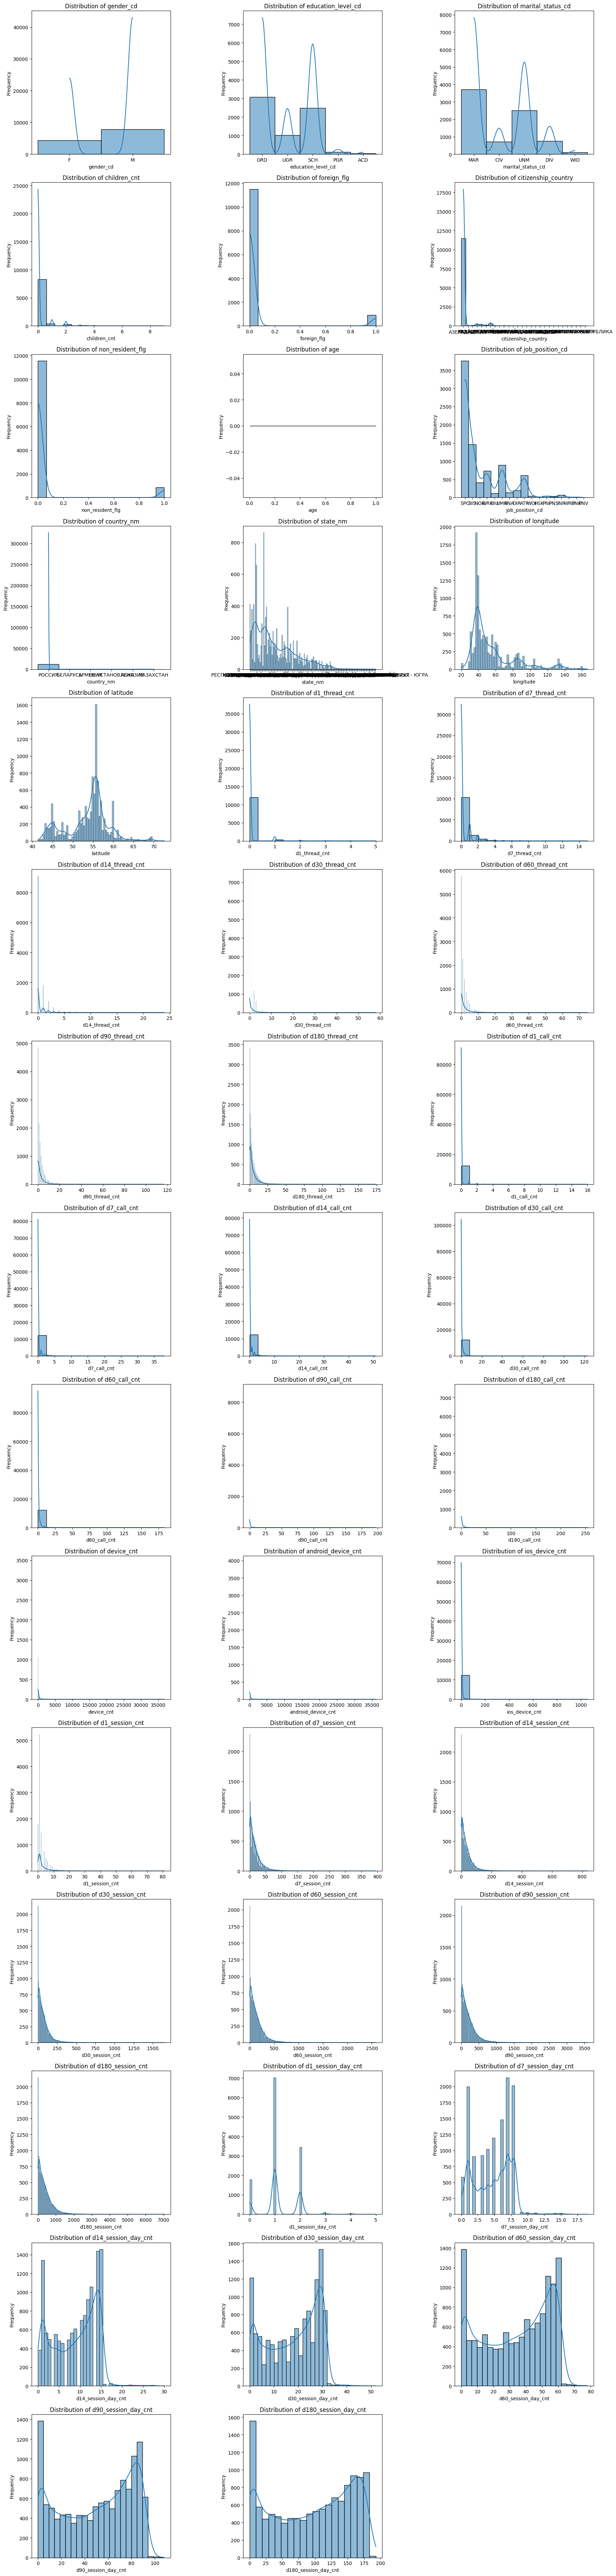

In [9]:
# Распределение фичей
import matplotlib.pyplot as plt
import seaborn as sns

num_columns = X_train.shape[1]
num_rows = (num_columns + 2) // 3

plt.figure(figsize=(18, 5 * num_rows))

for i, column in enumerate(X_train.columns):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(X_train[column], kde=True) # Use kde=True for kernel density estimate
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Обучаем модель

Проведем простейшую обработку и построим простенькую модель

In [10]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = load_data()

# Категориальные признаки для катбуста
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

X_train[categorical_features] = X_train[categorical_features].astype(str)
X_test[categorical_features] = X_test[categorical_features].astype(str)

# Train / Val
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    stratify=y_train,
    random_state=42
)


# Pools
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=categorical_features,
    feature_names=list(X_train.columns)
)

val_pool = Pool(
    data=X_val,
    label=y_val,
    cat_features=categorical_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=categorical_features
)


# Обучение модели с валидацией
model = CatBoostClassifier(
    cat_features=categorical_features,
    verbose=100,
    random_seed=42,
    eval_metric='AUC',
    early_stopping_rounds=50
)

model.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True
)


# Оценка модели
val_auc = roc_auc_score(y_val, model.predict_proba(val_pool)[:, 1])
test_auc = roc_auc_score(y_test, model.predict_proba(test_pool)[:, 1])

print("AUC Val:", "{:.3f}".format(val_auc))
print("AUC Test:", "{:.3f}".format(test_auc))

Learning rate set to 0.05588
0:	test: 0.6810926	best: 0.6810926 (0)	total: 76.4ms	remaining: 1m 16s
100:	test: 0.7190027	best: 0.7190487 (98)	total: 2.49s	remaining: 22.2s
200:	test: 0.7224613	best: 0.7225040 (183)	total: 4.89s	remaining: 19.4s
300:	test: 0.7237044	best: 0.7242012 (295)	total: 7.31s	remaining: 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7242381371
bestIteration = 319

Shrink model to first 320 iterations.
AUC Val: 0.724
AUC Test: 0.719


## 2. Значимость признаков

### Встроенная функция CatBoost

в метод get_feature_importance можно передавать type:
- "PredictionValuesChange" (как меняются предикты при удаленни признака или проставлении дефолтного значения - среднего например)
- "LossFunctionChange" (похож на permutation importance и использует функцию потерь)
- "ShapValues" (те самые значения Шепли)


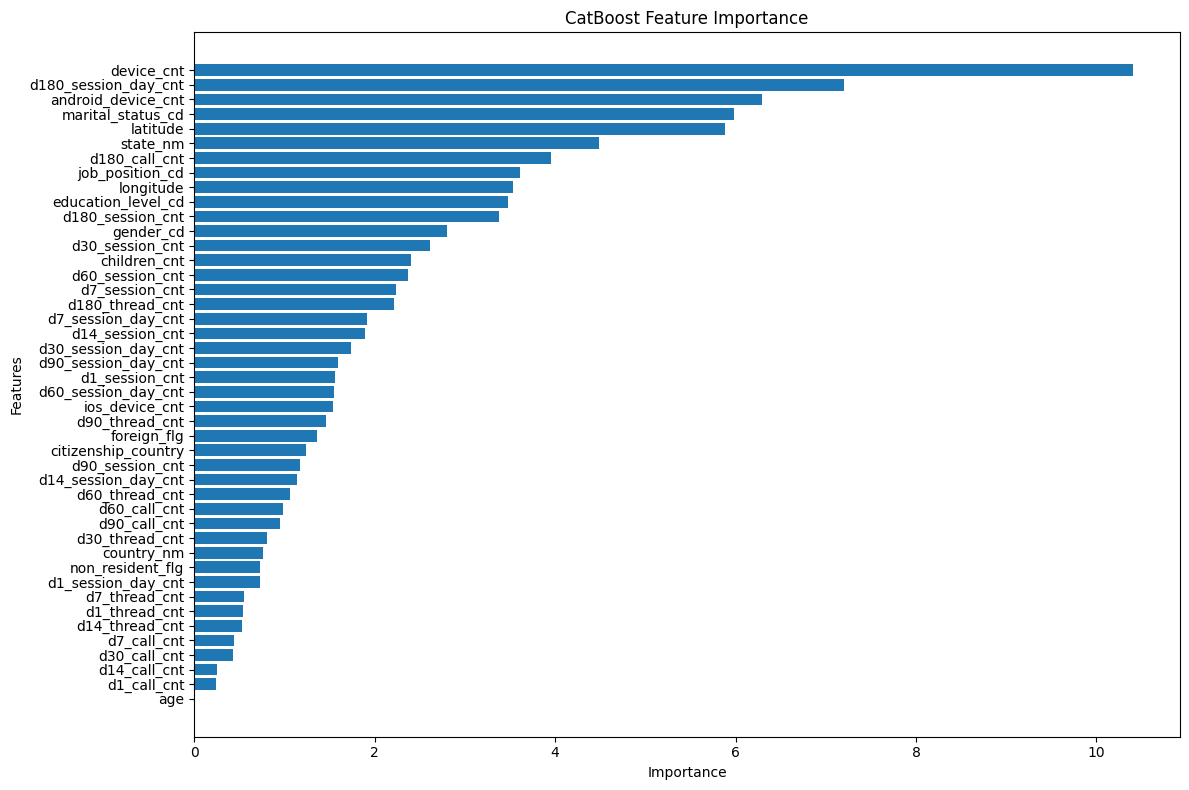

In [11]:
cat_importances = model.get_feature_importance(data=test_pool)
feature_importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': cat_importances})

feature_importance_df = feature_importance_df.sort_values('importance', ascending=True)

# Создаем график
plt.figure(figsize=(12, 8))
plt.title("CatBoost Feature Importance")
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Permutation importance

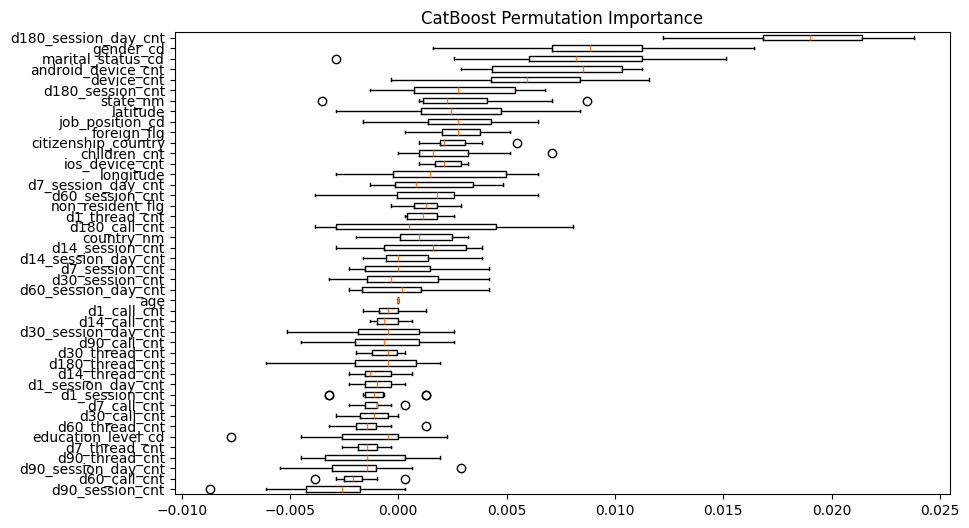

In [12]:
cat_result = permutation_importance(
    model
    ,X_test
    ,y_test
    ,n_repeats=10
    ,random_state=42
)

plt.figure(figsize=(10, 6))
plt.title("CatBoost Permutation Importance")
sorted_idx = cat_result.importances_mean.argsort()
plt.boxplot(
    cat_result.importances[sorted_idx].T,
    vert=False,
    tick_labels=X_test.columns[sorted_idx]
)

plt.show()

### SHAP средние значения

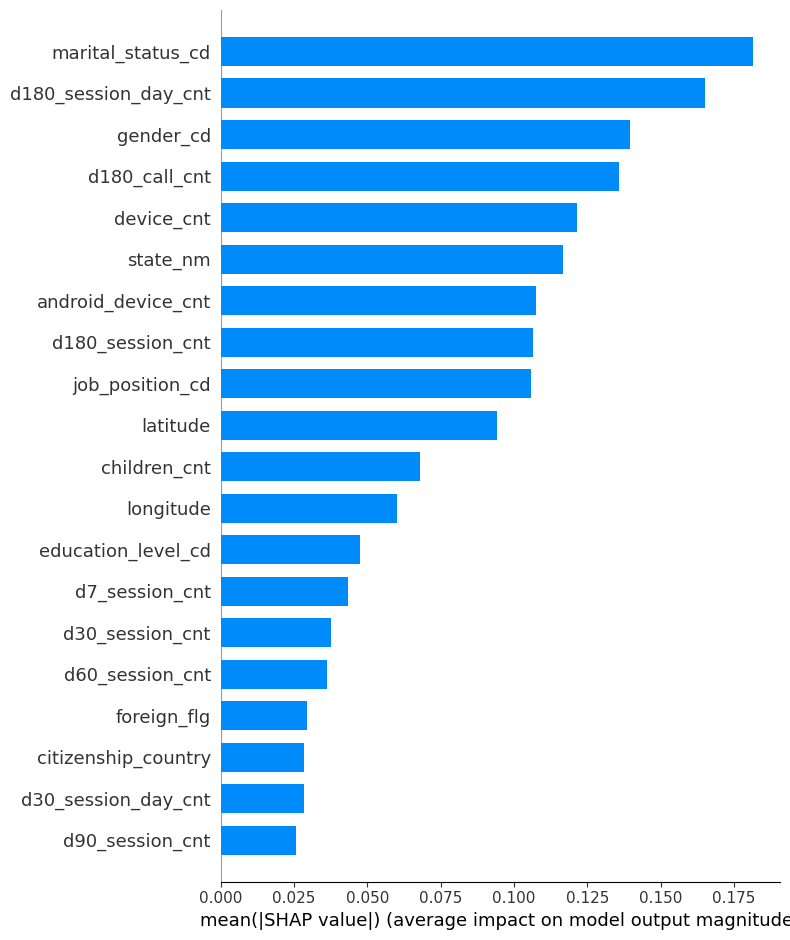

In [13]:
cat_importances = model.get_feature_importance(data=test_pool, type = 'ShapValues')

shap.summary_plot(
    cat_importances[:,:-1], 
    X_test, 
    plot_type="bar", #можно посмотреть как в виде "bar", так и в виде "dot"
    feature_names=X_test.columns
)

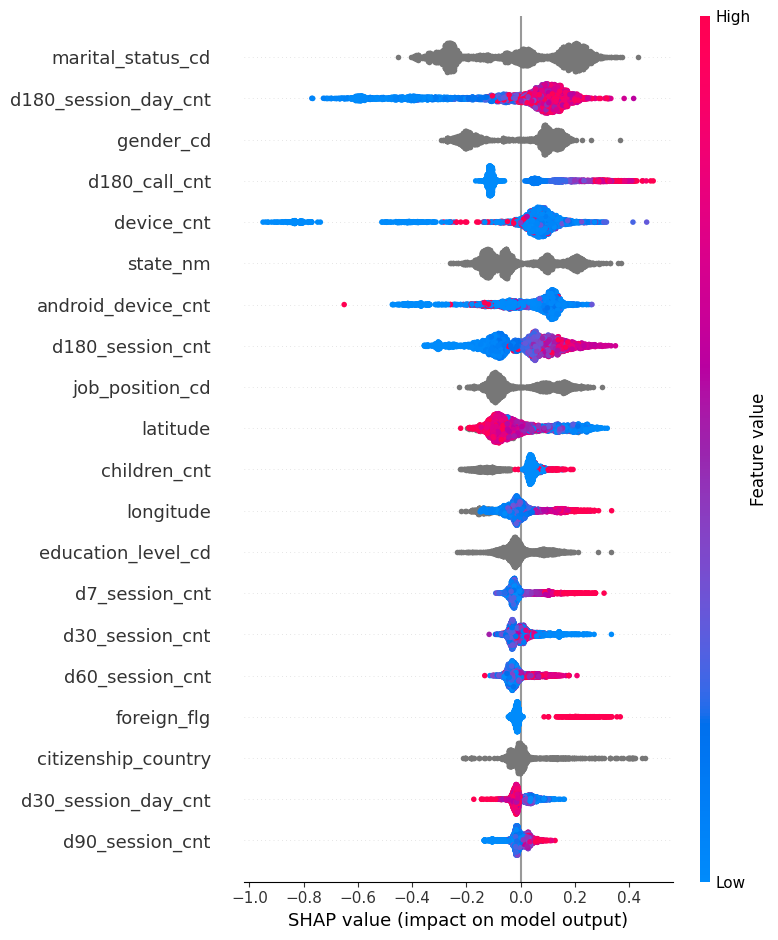

In [15]:
cat_importances = model.get_feature_importance(data=test_pool, type = 'ShapValues')


shap.summary_plot(
    cat_importances[:,:-1], 
    X_test, 
    plot_type="dot", #можно посмотреть как в виде "bar", так и в виде "dot"
    feature_names=X_test.columns
)

### SHAP по наблюдениям

In [16]:
observation_index = 10
observation_shap = cat_importances[observation_index]

In [17]:
observation_shap

array([ 0.15370865,  0.08750364,  0.05710568,  0.0391695 , -0.0085519 ,
        0.00399076, -0.00179739,  0.        , -0.1038564 ,  0.00384398,
        0.19146555,  0.27169289,  0.19358085, -0.00256493, -0.00185171,
       -0.000551  , -0.01994781, -0.00683463, -0.03854525, -0.01343668,
       -0.00073956, -0.00537084, -0.00483896, -0.00417492, -0.01514152,
       -0.01553511,  0.18360829,  0.05467542,  0.10590858,  0.00206426,
        0.01131425, -0.02775382, -0.02163717,  0.00290523, -0.03149357,
       -0.01477181, -0.05948083,  0.00844668,  0.00928797,  0.00300784,
        0.02571059,  0.03285991,  0.0229397 , -0.00371095, -0.08530654])

In [18]:
shap.force_plot(shap.Explanation(values=observation_shap[:-1], 
                                 base_values=observation_shap[-1], 
                                 data=X_test.iloc[observation_index], 
                                 feature_names=X_test.columns))

### Модель без неважных признаков

Опять же, обучим простую модель, без подбора гиперпараметров

In [41]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = load_data()

# Категориальные признаки для катбуста
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

X_train[categorical_features] = X_train[categorical_features].astype(str)
X_test[categorical_features] = X_test[categorical_features].astype(str)


n_splits = 5
top_percentages = [0.95, 0.9, 0.85, 0.8, 0.7]

# -------------------------
# Кросс-валидация
# -------------------------
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Словари для хранения результатов
results = {p: [] for p in top_percentages}
auc_all_features = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]
    
    # -------------------------
    # 1. CatBoost без отбора признаков
    # -------------------------
    model_all = CatBoostClassifier(
        eval_metric='AUC', verbose=0
    )
    model_all.fit(X_tr, y_tr, cat_features=cat_features)
    preds_all = model_all.predict_proba(X_val)[:,1]
    auc_all = roc_auc_score(y_val, preds_all)
    auc_all_features.append(auc_all)
    
    # -------------------------
    # 2. Вычисляем SHAP-важности
    # -------------------------

    tr_pool = Pool(
        data=X_tr,
        label=y_tr,
        cat_features=categorical_features,
        feature_names=list(X_tr.columns)
    )

    shap_values = model_all.get_feature_importance(
        type='ShapValues', data=tr_pool, fstr_type='FeatureImportance'
    )

    shap_values_features = shap_values[:-1]

    # Усредняем по абсолютному значению для каждого признака
    shap_importances = np.abs(shap_values_features).mean(axis=0)
    importances = pd.Series(shap_importances, index=X_tr.columns)
    importances_sorted = importances.sort_values(ascending=False)
    
    for p in top_percentages:
        k = max(1, int(len(importances_sorted) * p))  # гарантируем хотя бы 1 признак
        selected_features = importances_sorted.head(k).index.tolist()
        
        cat_feats_sel = [f for f in selected_features if f in cat_features]
        model_sel = CatBoostClassifier(
            eval_metric='AUC', verbose=0
        )
        model_sel.fit(X_tr[selected_features], y_tr, cat_features=cat_feats_sel)
        preds_sel = model_sel.predict_proba(X_val[selected_features])[:,1]
        auc_sel = roc_auc_score(y_val, preds_sel)
        results[p].append(auc_sel)
        
        print(f"Fold {fold}, top {int(p*100)}% features (SHAP): AUC = {auc_sel:.4f}, n_selected = {len(selected_features)}")

# -------------------------
# Сравнение моделей
# -------------------------
print("\nCross-validated results:")
print(f"All features: mean AUC = {np.mean(auc_all_features):.4f} ± {np.std(auc_all_features):.4f}")

for p in top_percentages:
    mean_auc = np.mean(results[p])
    std_auc = np.std(results[p])
    print(f"Top {int(p*100)}% features (SHAP): mean AUC = {mean_auc:.4f} ± {std_auc:.4f}")


Fold 1, top 95% features (SHAP): AUC = 0.7106, n_selected = 41
Fold 1, top 90% features (SHAP): AUC = 0.7099, n_selected = 39
Fold 1, top 85% features (SHAP): AUC = 0.7098, n_selected = 37
Fold 1, top 80% features (SHAP): AUC = 0.7074, n_selected = 35
Fold 1, top 70% features (SHAP): AUC = 0.7074, n_selected = 30
Fold 2, top 95% features (SHAP): AUC = 0.6939, n_selected = 41
Fold 2, top 90% features (SHAP): AUC = 0.6962, n_selected = 39
Fold 2, top 85% features (SHAP): AUC = 0.6913, n_selected = 37
Fold 2, top 80% features (SHAP): AUC = 0.6870, n_selected = 35
Fold 2, top 70% features (SHAP): AUC = 0.6845, n_selected = 30
Fold 3, top 95% features (SHAP): AUC = 0.6910, n_selected = 41
Fold 3, top 90% features (SHAP): AUC = 0.6930, n_selected = 39
Fold 3, top 85% features (SHAP): AUC = 0.6897, n_selected = 37
Fold 3, top 80% features (SHAP): AUC = 0.6928, n_selected = 35
Fold 3, top 70% features (SHAP): AUC = 0.6979, n_selected = 30
Fold 4, top 95% features (SHAP): AUC = 0.7155, n_select

## 3. Предположим, мы собрали сильно незначимые признаки

Создадим случайные признаки и добавим их в модель

In [24]:
X_train, X_test, y_train, y_test = load_data()

# cat features
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.to_list()
X_train[cat_features] = X_train[cat_features].astype(str)
X_test[cat_features] = X_test[cat_features].astype(str)

In [25]:
import numpy as np
rng = np.random.default_rng(100)

print(f'Old features dim: {X_train.shape[1]}')

n_random_features = 5
for i in range(n_random_features):
    col_name = f'random_{i+1}'
    X_train[col_name] = rng.random(X_train.shape[0])
    X_test[col_name] = rng.random(X_test.shape[0])

print(f'New features dim: {X_train.shape[1]}')

Old features dim: 44
New features dim: 49


In [26]:
# Train / Val
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    stratify=y_train,
    random_state=42
)

In [27]:
# Pools
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features,
    feature_names=list(X_train.columns)
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_features
)

val_pool = Pool(
    data=X_val,
    label=y_val,
    cat_features=cat_features
)


# Обучение модели с валидацией
model = CatBoostClassifier(
    cat_features=categorical_features,
    verbose=100,
    random_seed=42,
    early_stopping_rounds=50
)

model.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True
)


# Оценка модели
val_auc = roc_auc_score(y_val, model.predict_proba(val_pool)[:, 1])
test_auc = roc_auc_score(y_test, model.predict_proba(test_pool)[:, 1])

print("AUC Val:", "{:.3f}".format(val_auc))
print("AUC Test:", "{:.3f}".format(test_auc))

Learning rate set to 0.05588
0:	learn: 0.6862080	test: 0.6864161	best: 0.6864161 (0)	total: 35.1ms	remaining: 35.1s
100:	learn: 0.5922512	test: 0.6111958	best: 0.6111958 (100)	total: 2.57s	remaining: 22.9s
200:	learn: 0.5616973	test: 0.6079884	best: 0.6072226 (163)	total: 5.16s	remaining: 20.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6072225902
bestIteration = 163

Shrink model to first 164 iterations.
AUC Val: 0.720
AUC Test: 0.713


In [28]:
# было:
# AUC Test: 0.719

#### Посмотрим на значимость фичей

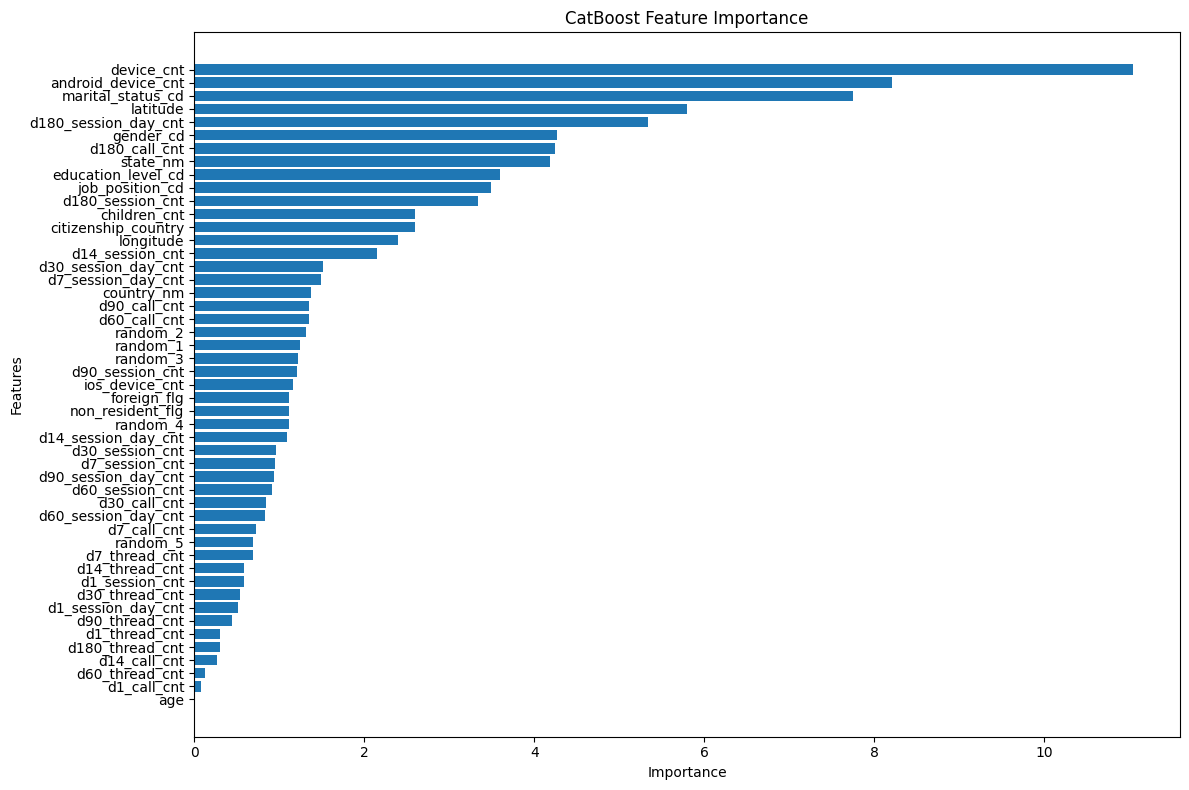

In [29]:
cat_importances = model.get_feature_importance(data=test_pool)
feature_importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': cat_importances})

feature_importance_df = feature_importance_df.sort_values('importance', ascending=True)

# Создаем график
plt.figure(figsize=(12, 8))
plt.title("CatBoost Feature Importance")
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

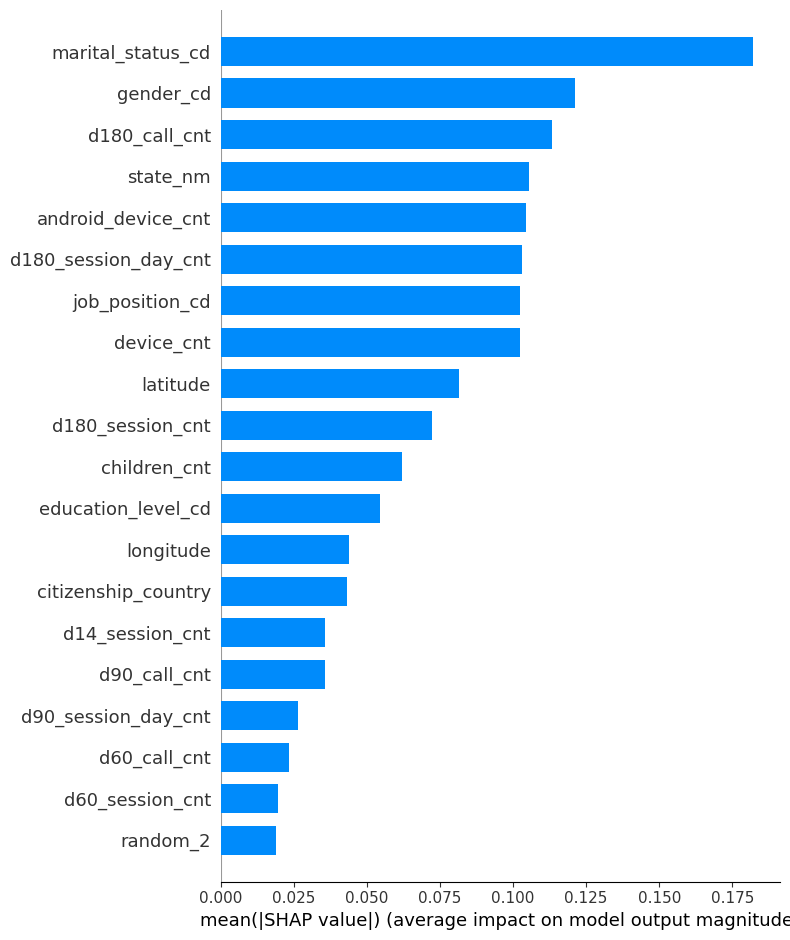

In [30]:
cat_importances = model.get_feature_importance(data=test_pool, type = 'ShapValues')

shap.summary_plot(
    cat_importances[:,:-1], 
    X_test, 
    plot_type="bar",
    feature_names=X_test.columns
)

### По кросс-валидации:

In [31]:
X_train, X_test, y_train, y_test = load_data()

In [32]:
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.to_list()
X_train[cat_features] = X_train[cat_features].astype(str)
X_test[cat_features] = X_test[cat_features].astype(str)

In [33]:
# аналогично добавляем рандомные колонки
import numpy as np
rng = np.random.default_rng(100)

print(f'Old features dim: {X_train.shape[1]}')

n_random_features = 5
for i in range(n_random_features):
    col_name = f'random_{i+1}'
    X_train[col_name] = rng.random(X_train.shape[0])
    X_test[col_name] = rng.random(X_test.shape[0])

print(f'New features dim: {X_train.shape[1]}')

Old features dim: 44
New features dim: 49


In [34]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

cat_features = X_train.select_dtypes(include='object').columns.tolist()
n_splits = 5
top_percentages = [0.95, 0.9, 0.8, 0.75, 0.7]

# -------------------------
# Кросс-валидация
# -------------------------
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Словари для хранения результатов
results = {p: [] for p in top_percentages}
auc_all_features = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]
    
    # -------------------------
    # 1. CatBoost
    # -------------------------
    model_all = CatBoostClassifier(
        eval_metric='AUC', verbose=0
    )
    model_all.fit(X_tr, y_tr, cat_features=cat_features)
    preds_all = model_all.predict_proba(X_val)[:,1]
    auc_all = roc_auc_score(y_val, preds_all)
    auc_all_features.append(auc_all)
    
    # -------------------------
    # 2. Вычисляем SHAP
    # -------------------------

    tr_pool = Pool(
        data=X_tr,
        label=y_tr,
        cat_features=categorical_features,
        feature_names=list(X_tr.columns)
    )

    shap_values = model_all.get_feature_importance(
        type='ShapValues', data=tr_pool, fstr_type='FeatureImportance'
    )

    shap_values_features = shap_values[:-1]

    # Усредняем по абсолютному значению для каждого признака
    shap_importances = np.abs(shap_values_features).mean(axis=0)
    importances = pd.Series(shap_importances, index=X_tr.columns)
    importances_sorted = importances.sort_values(ascending=False)
    
    for p in top_percentages:
        k = max(1, int(len(importances_sorted) * p))  # гарантируем хотя бы 1 признак
        selected_features = importances_sorted.head(k).index.tolist()
        
        cat_feats_sel = [f for f in selected_features if f in cat_features]
        model_sel = CatBoostClassifier(
            eval_metric='AUC', verbose=0
        )
        model_sel.fit(X_tr[selected_features], y_tr, cat_features=cat_feats_sel)
        preds_sel = model_sel.predict_proba(X_val[selected_features])[:,1]
        auc_sel = roc_auc_score(y_val, preds_sel)
        results[p].append(auc_sel)
        
        print(f"Fold {fold}, top {int(p*100)}% features (SHAP): AUC = {auc_sel:.4f}, n_selected = {len(selected_features)}")

# -------------------------
# Сравнение моделей
# -------------------------
print("\nCross-validated results:")
print(f"All features: mean AUC = {np.mean(auc_all_features):.4f} ± {np.std(auc_all_features):.4f}")

for p in top_percentages:
    mean_auc = np.mean(results[p])
    std_auc = np.std(results[p])
    print(f"Top {int(p*100)}% features (SHAP): mean AUC = {mean_auc:.4f} ± {std_auc:.4f}")

Fold 1, top 95% features (SHAP): AUC = 0.7095, n_selected = 46
Fold 1, top 90% features (SHAP): AUC = 0.7135, n_selected = 44
Fold 1, top 80% features (SHAP): AUC = 0.7099, n_selected = 39
Fold 1, top 75% features (SHAP): AUC = 0.7067, n_selected = 36
Fold 1, top 70% features (SHAP): AUC = 0.7078, n_selected = 34
Fold 2, top 95% features (SHAP): AUC = 0.6989, n_selected = 46
Fold 2, top 90% features (SHAP): AUC = 0.7003, n_selected = 44
Fold 2, top 80% features (SHAP): AUC = 0.6962, n_selected = 39
Fold 2, top 75% features (SHAP): AUC = 0.6855, n_selected = 36
Fold 2, top 70% features (SHAP): AUC = 0.6847, n_selected = 34
Fold 3, top 95% features (SHAP): AUC = 0.6914, n_selected = 46
Fold 3, top 90% features (SHAP): AUC = 0.6970, n_selected = 44
Fold 3, top 80% features (SHAP): AUC = 0.6930, n_selected = 39
Fold 3, top 75% features (SHAP): AUC = 0.6921, n_selected = 36
Fold 3, top 70% features (SHAP): AUC = 0.6935, n_selected = 34
Fold 4, top 95% features (SHAP): AUC = 0.7162, n_select

На 90% признаках качество модели лучше

### Если тренировать на всех данных:

In [39]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score

cat_features = X_train.select_dtypes(include='object').columns.tolist()

# ===========================================================
# 1. МОДЕЛЬ НА ВСЕХ ПРИЗНАКАХ
# ===========================================================

model_all = CatBoostClassifier(
    eval_metric='AUC',
    verbose=0
)

model_all.fit(
    X_train, y_train,
    cat_features=cat_features
)

preds_all = model_all.predict_proba(X_test)[:, 1]
auc_all = roc_auc_score(y_test, preds_all)

print(f"AUC (все признаки) = {auc_all:.4f}")


# ===========================================================
# 2. SHAP-фильтрация → топ-90% признаков → обучение модели
# ===========================================================

# --- Pool для вычисления SHAP ---
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features,
    feature_names=list(X_train.columns)
)

# Получаем SHAP-значения
shap_values = model_all.get_feature_importance(
    type='ShapValues',
    data=train_pool,
    fstr_type='FeatureImportance'
)

shap_features = shap_values[:-1] 
shap_importances = np.abs(shap_features).mean(axis=0)
importances = pd.Series(shap_importances, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=False)

# Выбираем ТОП-90% признаков
p = 0.90
k = max(1, int(len(importances_sorted) * p))
selected_features = importances_sorted.head(k).index.tolist()

print(f"Выбрано {len(selected_features)} признаков из {len(importances_sorted)} (топ-90%).")

cat_feats_sel = [f for f in selected_features if f in cat_features]

# -------------------------
# Обучаем модель на выбранных признаках
# -------------------------
model_sel = CatBoostClassifier(
    eval_metric='AUC',
    verbose=0
)

model_sel.fit(
    X_train[selected_features], y_train,
    cat_features=cat_feats_sel
)

preds_sel = model_sel.predict_proba(X_test[selected_features])[:, 1]
auc_sel = roc_auc_score(y_test, preds_sel)

print(f"AUC (топ-90% SHAP признаков) = {auc_sel:.4f}")

AUC (все признаки) = 0.7193
Выбрано 44 признаков из 49 (топ-90%).
AUC (топ-90% SHAP признаков) = 0.7219
